In [1]:
import numpy as np
import matplotlib.pyplot as plt

Calculating returns for Gamma type: fixed_low
Calculating returns for Gamma type: fixed_high
Calculating returns for Gamma type: dynamic_inc_linear
Calculating returns for Gamma type: dynamic_inc_nonlinear
Calculating returns for Gamma type: dynamic_dec_linear
Calculating returns for Gamma type: dynamic_dec_nonlinear


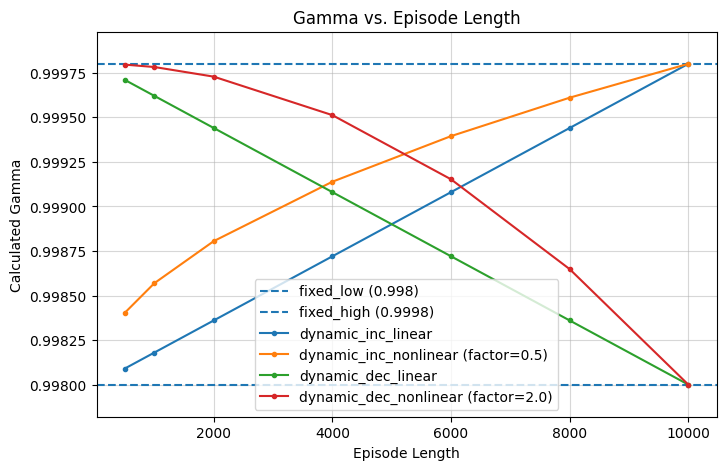

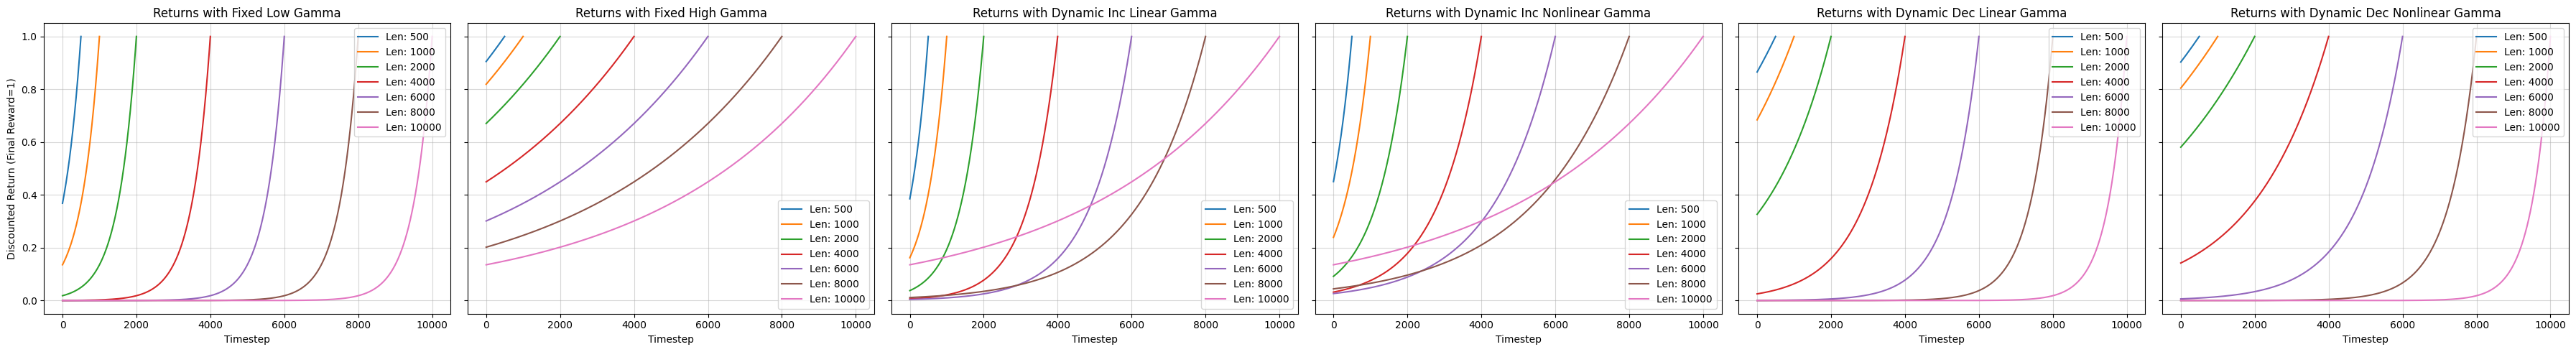

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Your existing functions ---
def get_dynamic_discount(episode_length, min_gamma=0.999, max_gamma=0.9998, max_expected_length=10000):
    normalized_length = min(episode_length / max_expected_length, 1.0)
    gamma = min_gamma + (max_gamma - min_gamma) * normalized_length
    return gamma

def get_dynamic_discount_nonlinear(
    episode_length, min_gamma=0.999, max_gamma=0.9998, max_expected_length=10000, nonlinear_scaling_factor=0.5 # User's original was 0.5
):
    # Note: factor < 1 -> slower increase initially. Factor > 1 -> faster increase initially.
    normalized_length = min(episode_length / max_expected_length, 1.0)
    scaled_length = normalized_length**nonlinear_scaling_factor
    gamma = min_gamma + (max_gamma - min_gamma) * scaled_length
    return gamma

# --- New functions for decreasing gamma ---
def get_dynamic_discount_decreasing(episode_length, min_gamma=0.999, max_gamma=0.9998, max_expected_length=10000):
    normalized_length = min(episode_length / max_expected_length, 1.0)
    gamma = max_gamma - (max_gamma - min_gamma) * normalized_length
    return gamma

def get_dynamic_discount_decreasing_nonlinear(
    episode_length, min_gamma=0.999, max_gamma=0.9998, max_expected_length=10000, nonlinear_scaling_factor=2 # Example > 1 for faster decrease
):
    # Note: factor > 1 -> faster decrease initially. Factor < 1 -> slower decrease initially.
    normalized_length = min(episode_length / max_expected_length, 1.0)
    scaled_length = normalized_length**nonlinear_scaling_factor
    gamma = max_gamma - (max_gamma - min_gamma) * scaled_length
    return gamma

def calculate_returns(rewards, gamma):
    returns = np.zeros_like(rewards, dtype=float)
    R = 0
    for t in reversed(range(len(rewards))):
        R = rewards[t] + gamma * R
        returns[t] = R
    return returns

def visualize_gamma_vs_length(episode_lengths, gammas, max_expected_length, nonlinear_factors):
    """Visualizes how gamma changes with episode length for dynamic strategies."""
    plt.figure(figsize=(8, 5))
    plt.title('Gamma vs. Episode Length')
    plt.xlabel('Episode Length')
    plt.ylabel('Calculated Gamma')

    lengths = np.array(episode_lengths)
    min_g, max_g = list(gammas.values())[0], list(gammas.values())[1] # Assumes fixed low/high are first

    for gamma_type, gamma_func_or_val in gammas.items():
        if callable(gamma_func_or_val):
            # Extract base function name if it's a lambda
            func_name = gamma_type
            if 'nonlinear' in func_name:
                 # Get the factor used for this specific type
                 factor = nonlinear_factors.get(gamma_type, 1.0) # Default to 1 if not found
                 current_gammas = [gamma_func_or_val(l) for l in lengths]
                 plt.plot(lengths, current_gammas, marker='.', linestyle='-', label=f'{func_name} (factor={factor:.1f})')
            else:
                 current_gammas = [gamma_func_or_val(l) for l in lengths]
                 plt.plot(lengths, current_gammas, marker='.', linestyle='-', label=func_name)
        else: # Fixed gammas
             plt.axhline(y=gamma_func_or_val, linestyle='--', label=f'{gamma_type} ({gamma_func_or_val})')


    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.ylim(min_g - (max_g - min_g) * 0.1, max_g + (max_g - min_g) * 0.1) # Adjust ylim slightly
    plt.show()


def visualize_returns(episode_lengths, gammas, all_returns):
    num_gammas = len(gammas)
    fig, axes = plt.subplots(1, num_gammas, figsize=(6 * num_gammas, 5), sharey=True)
    if not isinstance(axes, np.ndarray): axes = [axes]

    for i, gamma_type in enumerate(gammas):
        ax = axes[i]
        # Use descriptive titles based on the type name
        title = gamma_type.replace("_", " ").title()
        ax.set_title(f'Returns with {title} Gamma')
        ax.set_xlabel('Timestep')
        if i == 0: ax.set_ylabel('Discounted Return (Final Reward=1)')

        for length in episode_lengths:
            if length in all_calculated_returns[gamma_type]: # Check if data exists
                 returns = all_calculated_returns[gamma_type][length]
                 ax.plot(returns, label=f'Len: {length}')

        ax.legend()
        ax.grid(True, alpha=0.5)
        # Optional: Use log scale if returns vary widely, but can make comparison harder
        # ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

# --- Simulation Setup ---
episode_lengths_to_test = [500, 1000, 2000, 4000, 6000, 8000, 10000] # Adjusted for clarity
min_gamma_val = 0.998
max_gamma_val = 0.9998 # Increased range slightly for visibility
max_expected_episode_length = 10000
# Define distinct factors for different non-linear functions
nonlinear_factors = {
    'dynamic_inc_nonlinear': 0.5, # Slower increase
    'dynamic_dec_nonlinear': 2.0  # Faster decrease
}


# Define different gamma strategies - more descriptive names
gamma_strategies = {
    'fixed_low': min_gamma_val,
    'fixed_high': max_gamma_val,
    'dynamic_inc_linear': lambda length: get_dynamic_discount(length, min_gamma_val, max_gamma_val, max_expected_episode_length),
    'dynamic_inc_nonlinear': lambda length: get_dynamic_discount_nonlinear(
        length, min_gamma_val, max_gamma_val, max_expected_episode_length, nonlinear_factors['dynamic_inc_nonlinear']
    ),
     'dynamic_dec_linear': lambda length: get_dynamic_discount_decreasing(length, min_gamma_val, max_gamma_val, max_expected_episode_length),
    'dynamic_dec_nonlinear': lambda length: get_dynamic_discount_decreasing_nonlinear(
        length, min_gamma_val, max_gamma_val, max_expected_episode_length, nonlinear_factors['dynamic_dec_nonlinear']
    ),
}

all_calculated_returns = {gamma_type: {} for gamma_type in gamma_strategies}
calculated_gammas = {gamma_type: {} for gamma_type in gamma_strategies} # Store gammas too

# --- Calculation Loop ---
for gamma_type, gamma_value in gamma_strategies.items():
    print(f"Calculating returns for Gamma type: {gamma_type}")
    for episode_length in episode_lengths_to_test:
        # Get gamma value (either fixed or dynamic)
        if callable(gamma_value):
            current_gamma = gamma_value(episode_length)
        else:
            current_gamma = gamma_value
        calculated_gammas[gamma_type][episode_length] = current_gamma

        # Generate sparse rewards (1.0 at the end)
        rewards = [0.0] * (episode_length - 1) + [1.0]

        returns = calculate_returns(rewards, current_gamma)
        all_calculated_returns[gamma_type][episode_length] = returns
        # Optional: Print first return value to see the effect
        # print(f"  Len: {episode_length}, Gamma: {current_gamma:.6f}, R_0: {returns[0]:.6f}")


# --- Visualization ---
visualize_gamma_vs_length(episode_lengths_to_test, gamma_strategies, max_expected_episode_length, nonlinear_factors)
visualize_returns(episode_lengths_to_test, gamma_strategies, all_calculated_returns)